# Tarea 0 --- IELE756
**Team members**: [Renato Fernández] , [Vicente Vargas]
**Region**: [Undesignated]
**Date**: [05/03/2026]
# Objetivo

El objetivo de esta tarea es configurar el entorno de trabajo y realizar un primer acercamiento a los tres datasets utilizados en el curso: Censo 2024, ENO (Enfermedades de Notificación Obligatoria) y GRD (Egresos Hospitalarios).

In [28]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.1.4


## Part 1: Census 2024

Se cargan los datos del Censo en formato parquet utilizando solo algunas columnas para reducir el uso de memoria.

In [29]:
# 1.1 Load

import pandas as pd
persona = pd.read_parquet(
"personas_censo2024.parquet",
columns=["region", "comuna", "sexo", "edad",
"p27_nacionalidad", "p27_nacionalidad_rec",
"escolaridad", "sit_fuerza_trabajo"],
)

### Inspección de datos

Se revisa la estructura del dataset utilizando `.shape`, `.dtypes`, `.head()` y `.info()`.

In [30]:
# 1.2 Inspect

# Shape
print("Shape of the dataset:")
print(persona.shape)

print("\n")

# Data types
print("Data types:")
print(persona.dtypes)

print("\n")

# First 10 rows
print("First 10 rows:")
display(persona.head(10))

print("\n")

# General info
print("Dataset info:")
persona.info()

Shape of the dataset:
(18480432, 8)


Data types:
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object


First 10 rows:


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN




Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


### Filtrado por región

Se filtran las observaciones correspondientes a la Región Metropolitana de Santiago.

In [31]:
### 1.3 Filter to your region

my_region = persona[persona["region"] == 13]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 7,400,741


### Nacionalidad

Se analiza la distribución de la variable de nacionalidad y el porcentaje de personas extranjeras en la región.

In [32]:
# 1.4 First look at nationality

# Distribución de nacionalidad
nationality_distribution = my_region["p27_nacionalidad_rec"].value_counts()
print(nationality_distribution)

# Porcentaje de extranjeros
foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)

print(f"% foreign-born: {foreign.get('Extranjero', 0):.1%}")

p27_nacionalidad_rec
 1     6446621
 2      904819
-99      49301
Name: count, dtype: int64
% foreign-born: 0.0%


## Part 2: ENO — Notifiable Diseases

Se carga el dataset de enfermedades de notificación obligatoria (ENO) y se revisa su estructura general.

In [33]:
# 2.1 Load ENO dataset

eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
)

print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

C:\Users\aliro\AppData\Local\Temp\ipykernel_11652\3865677645.py:3: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


### Filtrado por región

Se seleccionan únicamente los registros correspondientes a la región.

In [34]:
# 2.2 Filter to your region

eno_region = eno[eno["region"] == "Región Metropolitana de Santiago"]

print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 126,669


### Notificaciones por año

Se cuentan las notificaciones por año para observar su evolución en el tiempo.

In [35]:
import matplotlib.pyplot as plt

# 2.3 Notifications by year

notifications_per_year = eno_region["anho_notificacion"].value_counts().sort_index()

print(notifications_per_year)


anho_notificacion
2007     3930
2008     3830
2009     4015
2010     4693
2011     6151
2012     5857
2013     6006
2014     6005
2015     6129
2016     6023
2017    10865
2018    13256
2019    10287
2020     7182
2021     7457
2022    10496
2023     9395
2024     5092
Name: count, dtype: int64


### Gráfico de notificaciones

Se muestra un gráfico de barras con el número de notificaciones por año.

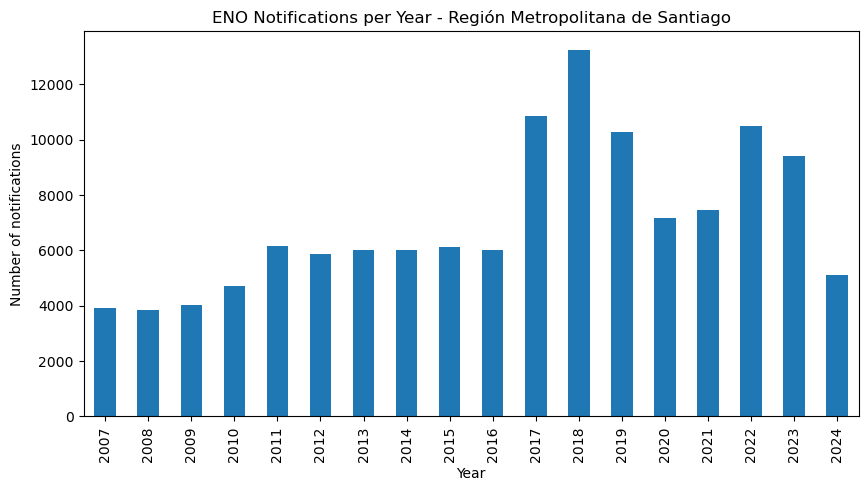

In [36]:

notifications_per_year.plot(kind="bar", figsize=(10,5))

plt.title("ENO Notifications per Year - Región Metropolitana de Santiago")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

plt.show()

### Enfermedades más notificadas

Se identifican las cinco enfermedades con mayor número de notificaciones en la región. 

In [37]:
# 2.4 Top 5 diseases

top_diseases = eno_region["ENO"].value_counts().head(5)

print(top_diseases)


ENO
Sifilis                 40928
VIH                     29097
Parotiditis             15493
Infección gonocócica     8766
Hepatitis B              7565
Name: count, dtype: int64


### Visualización de enfermedades

Se presenta un gráfico con las enfermedades más notificadas.

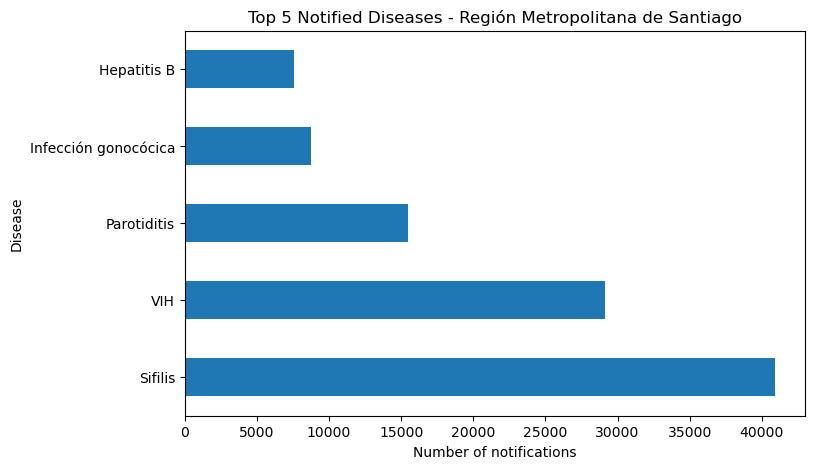

In [38]:
top_diseases.plot(kind="barh", figsize=(8,5))

plt.title("Top 5 Notified Diseases - Región Metropolitana de Santiago")
plt.xlabel("Number of notifications")
plt.ylabel("Disease")

plt.show()

### Nacionalidad

Se analiza la distribución de nacionalidad en los registros de ENO para la región.

In [39]:
# 2.5 Nationality distribution

nationality_distribution = eno_region["nacionalidad"].value_counts()

print(nationality_distribution)

nacionalidad
Desconocido    55863
Chile          47093
Extranjero     23713
Name: count, dtype: int64


## Part 3: GRD — Hospital Discharges

Se cargan los datos de egresos hospitalarios (GRD) desde un archivo comprimido, seleccionando solo algunas columnas para reducir el tamaño del dataset.

In [40]:
# 3.1 Load one year
import pandas as pd
import zipfile

cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
"FECHA_INGRESO", "FECHAALTA",
"IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(
            f,
            sep="|",
            usecols=cols,
            low_memory=False,
            encoding="latin-1"
        )

print(f"Total discharges: {len(grd):,}")
display(grd.head())

Total discharges: 1,085,813


,SEXO,COMUNA,NACIONALIDAD,FECHA_INGRESO,FECHAALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_SEVERIDAD
0,MUJER,VILLA ALEMANA,CHILE,2024-03-23,2024-03-23,H26.9,022360,0
1,MUJER,VIÑA DEL MAR,CHILE,2024-09-26,2024-10-02,M31.1,041023,3
2,HOMBRE,LA SERENA,CHILE,2024-01-22,2024-01-26,K12.2,034141,1
3,HOMBRE,ÑUÑOA,CHILE,2024-04-08,2024-04-14,C61,061203,3
4,MUJER,SAN PEDRO DE LA PAZ,PERÚ,2024-09-24,2024-09-26,K35.8,061131,1


### Filtrado por región

Se filtran los registros utilizando las comunas que pertenecen a la comuna asignada (Maipú).

In [41]:
# 3.2 Filter to your region (Maipú)

my_comunas = ["MAIPU"]

grd_region = grd[grd["COMUNA"].isin(my_comunas)]

print(f"Discharges in Maipú: {len(grd_region):,}")

Discharges in Maipú: 21,493


### Join con CIE-10

Se carga la tabla CIE-10 y se unen los códigos de diagnóstico con su descripción para facilitar la interpretación de los diagnósticos en los datos hospitalarios.

In [42]:
# 3.3 Join with CIE-10

cie10 = pd.read_excel(
    "CIE-10.xlsx",
    sheet_name="CIE 10"
)

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

grd_region[["DIAGNOSTICO1", "Descripción"]].head()

,DIAGNOSTICO1,Descripción
0,Z51.2,Otra quimioterapia
1,P07.3,Otros recién nacidos pretérmino
2,Z43.0,Atención de traqueostomía
3,D10.3,Tumor benigno de otras partes y de las no espe...
4,K25.0,"Úlcera gástrica, aguda con hemorragia"


### Diagnósticos más frecuentes

Se identifican los cinco diagnósticos más comunes en la región.

In [43]:
# 3.4 Top 5 diagnoses

top5_diagnoses = grd_region["Descripción"].value_counts().head(5)

print(top5_diagnoses)


Descripción
Cálculo de la vesícula biliar sin colecistitis          395
Desgarro perineal de primer grado durante el parto      345
Cálculo de la vesícula biliar con colecistitis aguda    329
Apendicitis aguda, otra y no especificada               283
Otras atenciones médicas especificadas                  276
Name: count, dtype: int64


### Visualización

Se muestra un gráfico de barras con los diagnósticos más frecuentes.

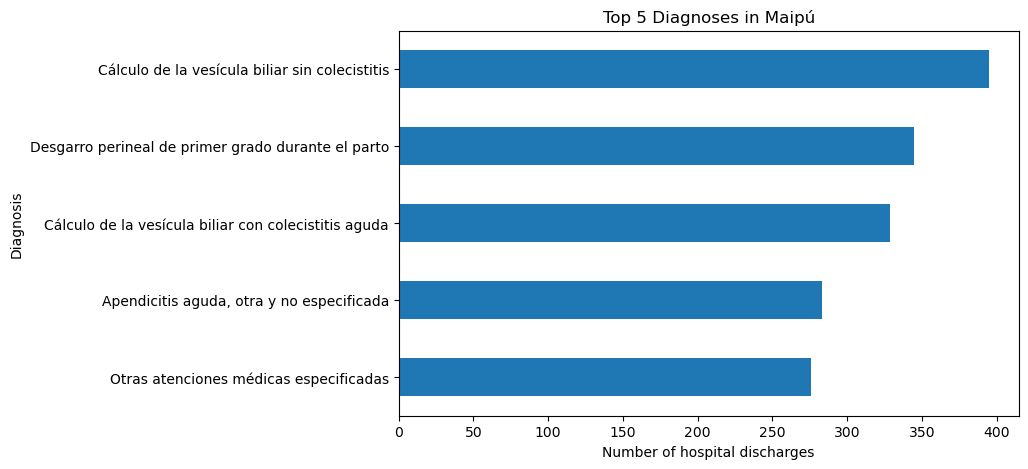

In [44]:
top5_diagnoses.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Top 5 Diagnoses in Maipú")
plt.xlabel("Number of hospital discharges")
plt.ylabel("Diagnosis")

plt.show()